# Manufacturing Defect Rate Analysis & Root Cause Modelling
### Dataset used: UCI SECOM Semiconductor Manufacturing

## Import Libraries

In [25]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns


from scipy import stats        

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110



##  Load the SECOM Dataset

In [26]:
# ── Load directly from UCI repository ────────────────────────────
DATA_URL   = 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom.data'
LABELS_URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/secom/secom_labels.data'

print('Downloading SECOM sensor data...')
X_raw = pd.read_csv(DATA_URL, sep=' ', header=None)

print('Downloading labels...')
labels = pd.read_csv(LABELS_URL, sep=' ', header=None, names=['label', 'timestamp'])

# Rename sensor columns for clarity
X_raw.columns = [f'sensor_{i+1}' for i in range(X_raw.shape[1])]

# Map labels: -1 (pass) → 0,  1 (fail/defect) → 1
y = labels['label'].map({-1: 0, 1: 1})

print(f'\nData shape   : {X_raw.shape}  (rows x sensors)')
print(f'Label shape  : {y.shape}')
print(f'\nClass distribution:')
print(y.value_counts().rename({0:'Pass (0)', 1:'Fail/Defect (1)'}).to_string())
print(f'\nDefect rate  : {y.mean()*100:.1f}%')


Data shape   : (1567, 590)  (rows x sensors)
Label shape  : (1567,)

Class distribution:
label
Pass (0)           1463
Fail/Defect (1)     104

Defect rate  : 6.6%



##  Data Cleaning


In [27]:
print('First 5 rows (first 10 sensors only) ')
display(X_raw.iloc[:5, :10])

print('\n Basic statistics (first 8 sensors) ')
display(X_raw.iloc[:, :8].describe().round(2))

# Missing value overview
missing_pct = (X_raw.isnull().sum() / len(X_raw) * 100)
print(f'\n=== Missing Value Summary ===')
print(f'Sensors with NO missing values   : {(missing_pct == 0).sum()}')
print(f'Sensors with 1–20% missing       : {((missing_pct > 0) & (missing_pct <= 20)).sum()}')
print(f'Sensors with 20–50% missing      : {((missing_pct > 20) & (missing_pct <= 50)).sum()}')
print(f'Sensors with >50% missing        : {(missing_pct > 50).sum()}')

First 5 rows (first 10 sensors only) 


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031



 Basic statistics (first 8 sensors) 


,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8
count,1561.00,1560.00,1553.00,1553.00,1553.00,1553.0,1553.00,1558.00
mean,3014.45,2495.85,2200.55,1396.38,4.20,100.0,101.11,0.12
std,73.62,80.41,29.51,441.69,56.36,0.0,6.24,0.01
min,2743.24,2158.75,2060.66,0.00,0.68,100.0,82.13,0.00
25%,2966.26,2452.25,2181.04,1081.88,1.02,100.0,97.92,0.12
50%,3011.49,2499.40,2201.07,1285.21,1.32,100.0,101.51,0.12
75%,3056.65,2538.82,2218.06,1591.22,1.53,100.0,104.59,0.12
max,3356.35,2846.44,2315.27,3715.04,1114.54,100.0,129.25,0.13



=== Missing Value Summary ===
Sensors with NO missing values   : 52
Sensors with 1–20% missing       : 506
Sensors with 20–50% missing      : 4
Sensors with >50% missing        : 28


In [28]:
print('--- Step 1: Drop sensors with >50% missing values ---')
missing_pct = X_raw.isnull().sum() / len(X_raw)
cols_to_drop_missing = missing_pct[missing_pct > 0.50].index.tolist()
X = X_raw.drop(columns=cols_to_drop_missing)
print(f'Dropped {len(cols_to_drop_missing)} sensors  |  Remaining: {X.shape[1]}')

print('\n--- Step 2: Drop zero-variance (constant) sensors ---')
# A sensor that never changes cannot help distinguish pass vs fail
variance = X.var()
cols_to_drop_const = variance[variance == 0].index.tolist()
X = X.drop(columns=cols_to_drop_const)
print(f'Dropped {len(cols_to_drop_const)} constant sensors  |  Remaining: {X.shape[1]}')

print('\n--- Step 3: Impute remaining NaN with column median ---')
# Median imputation is preferred over mean when data has outliers (common in sensor data)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X),columns=X.columns)

print(f'Missing values after imputation  : {X_imputed.isnull().sum().sum()}')

print(f'\n clean dataset shape      : {X_imputed.shape}')

--- Step 1: Drop sensors with >50% missing values ---
Dropped 28 sensors  |  Remaining: 562

--- Step 2: Drop zero-variance (constant) sensors ---
Dropped 116 constant sensors  |  Remaining: 446

--- Step 3: Impute remaining NaN with column median ---
Missing values after imputation  : 0

 clean dataset shape      : (1567, 446)



## Exploratory Data Analysis (EDA)

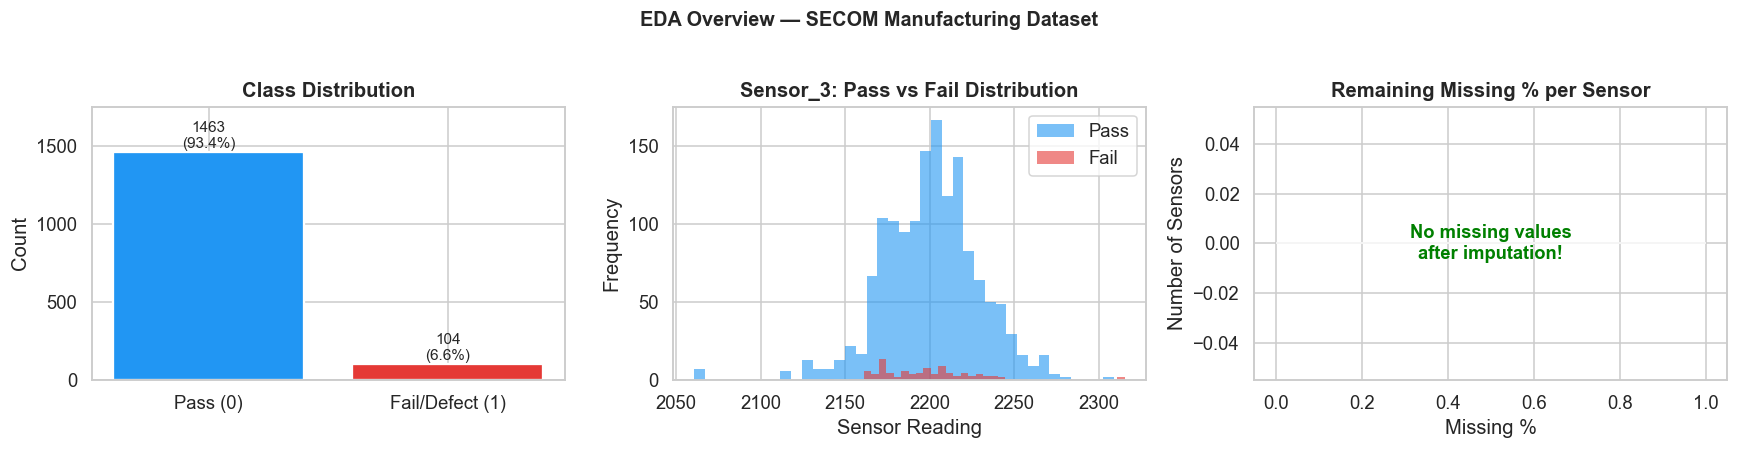

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Plot 1: Class distribution ────────────────────────────────────
counts = y.value_counts()
bars = axes[0].bar(['Pass (0)', 'Fail/Defect (1)'], counts.values,
                   color=['#2196F3', '#E53935'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{val}\n({val/len(y)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
axes[0].set_ylim(0, counts.max() * 1.2)

# ── Plot 2: Sensor distribution — pass vs fail comparison ────────
temp_df = X_imputed[['sensor_3']].copy()
temp_df['label'] = y.values
for label, color, name in [(0, '#2196F3', 'Pass'), (1, '#E53935', 'Fail')]:
    axes[1].hist(temp_df[temp_df['label'] == label]['sensor_3'],
                 bins=40, alpha=0.6, color=color, label=name, edgecolor='none')
axes[1].set_title('Sensor_3: Pass vs Fail Distribution', fontweight='bold')
axes[1].set_xlabel('Sensor Reading')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# ── Plot 3: Missing value pattern (post-cleaning) ─────────────────
still_missing = (X_imputed.isnull().sum() / len(X_imputed) * 100)
axes[2].hist(still_missing[still_missing > 0], bins=20,
             color='#FF9800', edgecolor='white')
axes[2].set_title('Remaining Missing % per Sensor', fontweight='bold')
axes[2].set_xlabel('Missing %')
axes[2].set_ylabel('Number of Sensors')
if still_missing.max() == 0:
    axes[2].text(0.5, 0.5, 'No missing values\nafter imputation!',
                 transform=axes[2].transAxes, ha='center', va='center',
                 fontsize=12, color='green', fontweight='bold')

plt.suptitle('EDA Overview — SECOM Manufacturing Dataset', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



##  Statistical Hypothesis Testing

In [33]:
pass_idx = y[y == 0].index
fail_idx = y[y == 1].index

results = []
for col in X_imputed.columns:
    pass_vals = X_imputed.loc[pass_idx, col].values
    fail_vals = X_imputed.loc[fail_idx, col].values
    stat, p_val = stats.mannwhitneyu(pass_vals, fail_vals, alternative='two-sided')
    results.append({'sensor': col, 'p_value': p_val, 'statistic': stat})

stats_df = pd.DataFrame(results).sort_values('p_value')

# Applying Bonferroni correction 
# Conservative threshold: p < 0.05 / n_tests
n_tests = len(stats_df)
bonferroni_threshold = 0.05 / n_tests
significant = stats_df[stats_df['p_value'] < 0.05]
highly_significant = stats_df[stats_df['p_value'] < bonferroni_threshold]

print(f'Total sensors tested             : {n_tests}')
print(f'Significant at p < 0.05          : {len(significant)}')
print(f'Significant after Bonferroni     : {len(highly_significant)}')
print(f'Bonferroni threshold             : {bonferroni_threshold:.6f}')
print(f'\nTop 10 most significant sensors:')
print(stats_df.head(10)[['sensor', 'p_value']].to_string(index=False))

Total sensors tested             : 446
Significant at p < 0.05          : 86
Significant after Bonferroni     : 9
Bonferroni threshold             : 0.000112

Top 10 most significant sensors:
    sensor      p_value
 sensor_60 5.181701e-11
sensor_104 9.434706e-09
sensor_248 9.788141e-07
sensor_520 1.029350e-06
sensor_511 3.420323e-06
sensor_478 3.442858e-05
sensor_130 4.644758e-05
sensor_206 4.662632e-05
 sensor_29 7.445539e-05
sensor_386 1.474187e-04



##  Visualizing Top Significant Sensors


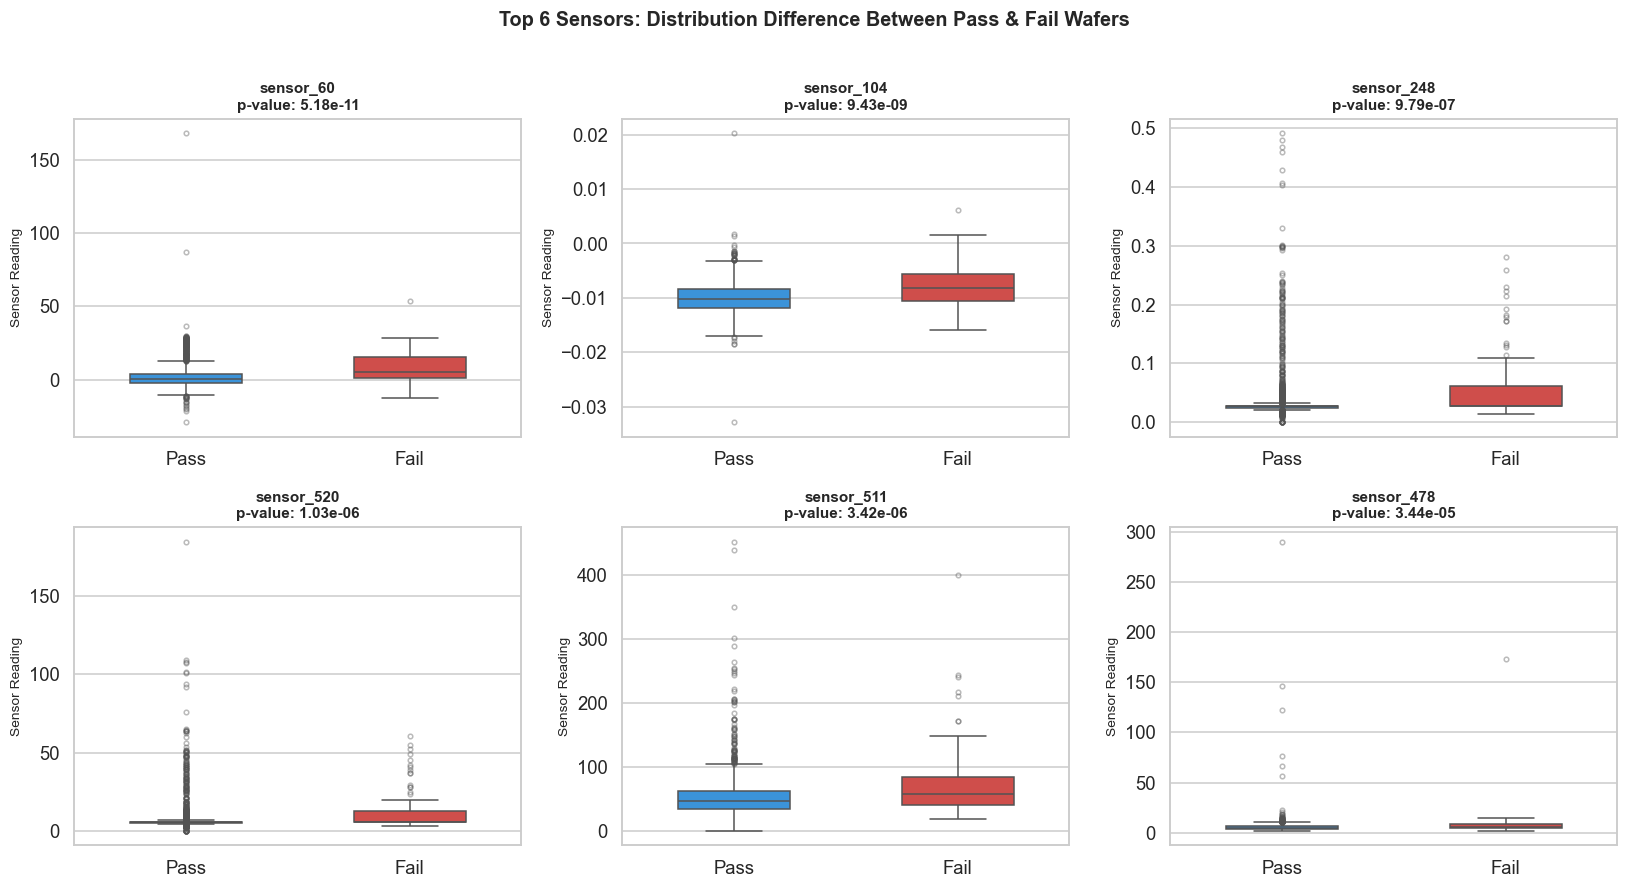

In [34]:
top6 = stats_df.head(6)['sensor'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

plot_df = X_imputed[top6].copy()
plot_df['Outcome'] = y.map({0: 'Pass', 1: 'Fail'}).values

for i, sensor in enumerate(top6):
    sns.boxplot(
        data=plot_df, x='Outcome', y=sensor,
        palette={'Pass': '#2196F3', 'Fail': '#E53935'},
        ax=axes[i], width=0.5, flierprops={'markersize': 3, 'alpha': 0.4}
    )
    p_val = stats_df[stats_df['sensor'] == sensor]['p_value'].values[0]
    axes[i].set_title(f'{sensor}\np-value: {p_val:.2e}', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Sensor Reading', fontsize=9)

plt.suptitle('Top 6 Sensors: Distribution Difference Between Pass & Fail Wafers',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Prepare Data for Modelling


In [35]:
# Use sensors significant at p < 0.05
selected_features = significant['sensor'].tolist()
print(f'Features selected for modelling  : {len(selected_features)}')

X_selected = X_imputed[selected_features]

# Train/test split — stratified to preserve class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.20, random_state=42, stratify=y
)

print(f'\nTrain set size : {X_train.shape[0]} samples')
print(f'Test set size  : {X_test.shape[0]} samples')
print(f'\nClass balance in train set:')
print(y_train.value_counts(normalize=True).rename({0:'Pass', 1:'Fail'}).round(3).to_string())
print(f'\nClass balance in test set:')
print(y_test.value_counts(normalize=True).rename({0:'Pass', 1:'Fail'}).round(3).to_string())

Features selected for modelling  : 86

Train set size : 1253 samples
Test set size  : 314 samples

Class balance in train set:
label
Pass    0.934
Fail    0.066

Class balance in test set:
label
Pass    0.933
Fail    0.067


## Logistic Regression Model


In [36]:
# StandardScaler is REQUIRED for Logistic Regression — features must be on same scale
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',   # handles imbalance
        max_iter=1000,
        random_state=42,
        C=0.1     # L2 regularisation to prevent overfitting
    ))
])

lr_pipeline.fit(X_train, y_train)

# Cross-validation score (more reliable than single train/test split)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_pipeline, X_selected, y, cv=cv, scoring='roc_auc')

print('=== Logistic Regression — Cross Validation ===')
print(f'ROC-AUC per fold : {[round(s, 3) for s in cv_scores]}')
print(f'Mean ROC-AUC     : {cv_scores.mean():.3f}  (± {cv_scores.std():.3f})')

y_pred_lr  = lr_pipeline.predict(X_test)
y_prob_lr  = lr_pipeline.predict_proba(X_test)[:, 1]

print('\n=== Test Set Classification Report ===')
print(classification_report(y_test, y_pred_lr, target_names=['Pass', 'Fail/Defect']))
print(f'Test ROC-AUC     : {roc_auc_score(y_test, y_prob_lr):.3f}')

=== Logistic Regression — Cross Validation ===
ROC-AUC per fold : [np.float64(0.799), np.float64(0.773), np.float64(0.697), np.float64(0.683), np.float64(0.663)]
Mean ROC-AUC     : 0.723  (± 0.053)

=== Test Set Classification Report ===
              precision    recall  f1-score   support

        Pass       0.95      0.75      0.84       293
 Fail/Defect       0.11      0.43      0.17        21

    accuracy                           0.73       314
   macro avg       0.53      0.59      0.51       314
weighted avg       0.89      0.73      0.79       314

Test ROC-AUC     : 0.668



## Random Forest Model (Comparison)

In [37]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)

cv_scores_rf = cross_val_score(rf_pipeline, X_selected, y, cv=cv, scoring='roc_auc')

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print('=== Random Forest — Cross Validation ===')
print(f'ROC-AUC per fold : {[round(s, 3) for s in cv_scores_rf]}')
print(f'Mean ROC-AUC     : {cv_scores_rf.mean():.3f}  (± {cv_scores_rf.std():.3f})')
print('\n=== Test Set Classification Report ===')
print(classification_report(y_test, y_pred_rf, target_names=['Pass', 'Fail/Defect']))
print(f'Test ROC-AUC     : {roc_auc_score(y_test, y_prob_rf):.3f}')

print('\n=== Model Comparison Summary ===')
print(f'{"Model":<25} {"CV ROC-AUC":>12} {"Test ROC-AUC":>14}')
print('-' * 52)
print(f'{"Logistic Regression":<25} {cv_scores.mean():>12.3f} {roc_auc_score(y_test, y_prob_lr):>14.3f}')
print(f'{"Random Forest":<25} {cv_scores_rf.mean():>12.3f} {roc_auc_score(y_test, y_prob_rf):>14.3f}')

=== Random Forest — Cross Validation ===
ROC-AUC per fold : [np.float64(0.821), np.float64(0.78), np.float64(0.787), np.float64(0.732), np.float64(0.735)]
Mean ROC-AUC     : 0.771  (± 0.034)

=== Test Set Classification Report ===
              precision    recall  f1-score   support

        Pass       0.94      1.00      0.97       293
 Fail/Defect       1.00      0.10      0.17        21

    accuracy                           0.94       314
   macro avg       0.97      0.55      0.57       314
weighted avg       0.94      0.94      0.92       314

Test ROC-AUC     : 0.765

=== Model Comparison Summary ===
Model                       CV ROC-AUC   Test ROC-AUC
----------------------------------------------------
Logistic Regression              0.723          0.668
Random Forest                    0.771          0.765



## Model Evaluation Visualisations

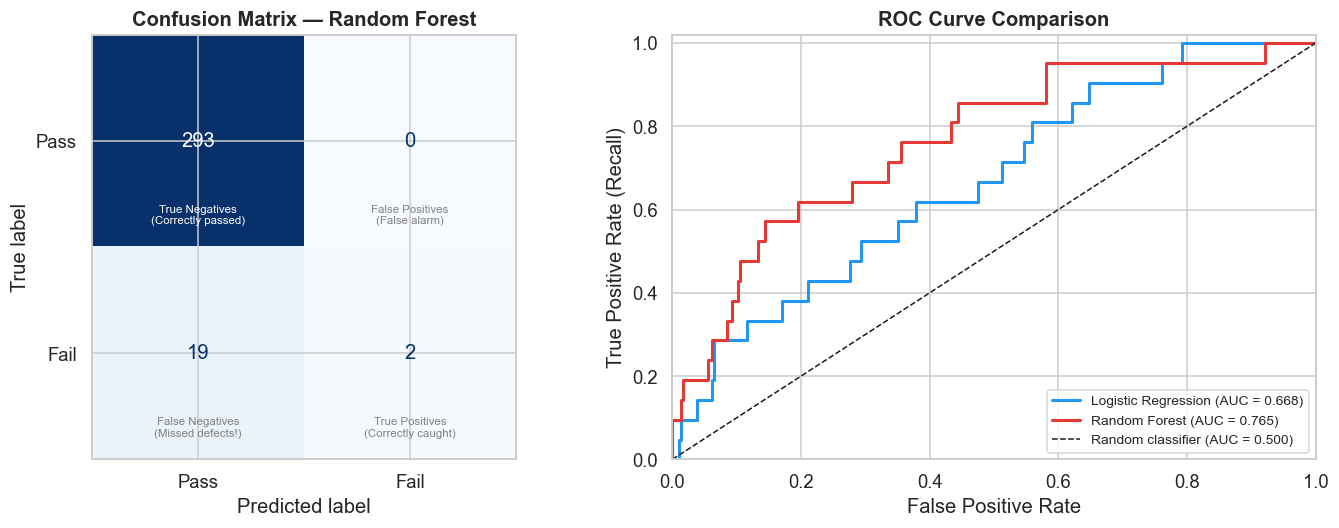

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Plot 1: Confusion Matrix (Random Forest) ──────────────────────
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Fail'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — Random Forest', fontweight='bold')

# Annotate what each quadrant means
annotations = [
    (0, 0, 'True Negatives\n(Correctly passed)'),
    (0, 1, 'False Positives\n(False alarm)'),
    (1, 0, 'False Negatives\n(Missed defects!)'),
    (1, 1, 'True Positives\n(Correctly caught)')
]
for row, col, label in annotations:
    axes[0].text(col, row + 0.35, label, ha='center', va='center',
                 fontsize=7.5, color='white' if cm[row, col] > cm.max()/2 else 'gray')

# ── Plot 2: ROC Curves ────────────────────────────────────────────
for y_prob, label, color in [
    (y_prob_lr, 'Logistic Regression', '#2196F3'),
    (y_prob_rf, 'Random Forest',       '#E53935')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier (AUC = 0.500)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()


---
## Feature Importance: Which Sensors Drive Defects

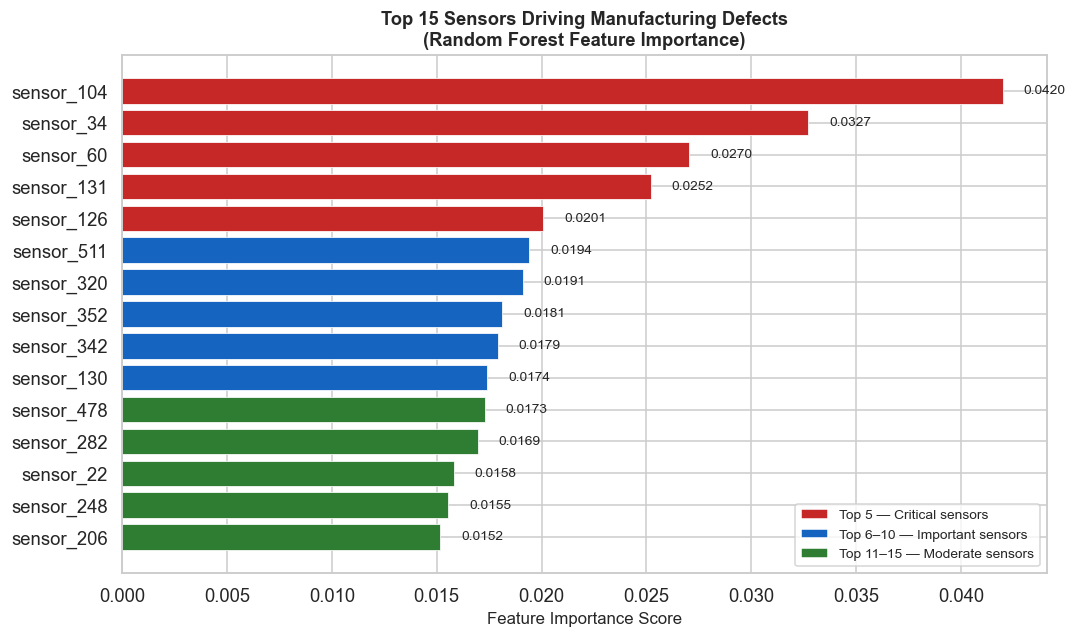

Top 5 most important sensors:
  1. sensor_104       importance = 0.0420
  2. sensor_34        importance = 0.0327
  3. sensor_60        importance = 0.0270
  4. sensor_131       importance = 0.0252
  5. sensor_126       importance = 0.0201


In [39]:
# Extracting feature importances from the Random Forest inside the pipeline
rf_model = rf_pipeline.named_steps['model']
importances = pd.Series(
    rf_model.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

top_n = 15
top_features = importances.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#C62828' if i < 5 else '#1565C0' if i < 10 else '#2E7D32'
          for i in range(top_n)]
bars = ax.barh(top_features.index[::-1], top_features.values[::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.5)

for bar, val in zip(bars, top_features.values[::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)

ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_title(f'Top {top_n} Sensors Driving Manufacturing Defects\n(Random Forest Feature Importance)',
             fontweight='bold', fontsize=12)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C62828', label='Top 5 — Critical sensors'),
    Patch(facecolor='#1565C0', label='Top 6–10 — Important sensors'),
    Patch(facecolor='#2E7D32', label='Top 11–15 — Moderate sensors')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

print('Top 5 most important sensors:')
for i, (sensor, score) in enumerate(importances.head(5).items(), 1):
    print(f'  {i}. {sensor:15s}  importance = {score:.4f}')


## Summary



In [40]:
total_wafers    = len(y)
defective       = y.sum()
defect_rate_pct = defective / total_wafers * 100

# Model recall on defects (what % of actual defects did we catch?)
from sklearn.metrics import recall_score
defect_recall = recall_score(y_test, y_pred_rf)

# Hypothetical cost savings
cost_per_defect_usd       = 500    # estimated rework cost per defective wafer
defects_in_test           = y_test.sum()
defects_caught_by_model   = int(defect_recall * defects_in_test)
cost_saving_test_set      = defects_caught_by_model * cost_per_defect_usd

top5_sensors = importances.head(5).index.tolist()
top5_importance_pct = importances.head(5).sum() / importances.sum() * 100

print('=' * 65)
print('       SUMMARY')
print('=' * 65)
print(f'''
DATASET OVERVIEW
  Total wafers analysed       : {total_wafers:,}
  Defective wafers            : {defective:,}  ({defect_rate_pct:.1f}% defect rate)
  Process sensors analysed    : {X_imputed.shape[1]}

MODEL PERFORMANCE (Random Forest)
  Cross-validated ROC-AUC     : {cv_scores_rf.mean():.3f}
  Defect recall on test set   : {defect_recall:.1%}
  (i.e. the model correctly identified {defect_recall:.1%} of actual defects)

KEY FINDING
  The top 5 sensors account for {top5_importance_pct:.1f}% of total predictive power:
  → {', '.join(top5_sensors)}

  These sensors show statistically significant differences (p < 0.05,
  Mann-Whitney U test) between passing and failing wafers.


''')


       SUMMARY

DATASET OVERVIEW
  Total wafers analysed       : 1,567
  Defective wafers            : 104  (6.6% defect rate)
  Process sensors analysed    : 446

MODEL PERFORMANCE (Random Forest)
  Cross-validated ROC-AUC     : 0.771
  Defect recall on test set   : 9.5%
  (i.e. the model correctly identified 9.5% of actual defects)

KEY FINDING
  The top 5 sensors account for 14.7% of total predictive power:
  → sensor_104, sensor_34, sensor_60, sensor_131, sensor_126

  These sensors show statistically significant differences (p < 0.05,
  Mann-Whitney U test) between passing and failing wafers.



